# Dependencies


In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import googlemaps
from ares import logger
import os
from pathlib import Path
from dotenv import load_dotenv
from ares.utils.common import load_json, save_json
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)


df = pd.read_csv("../artifacts/data/01-raw/untouched_raw_original.csv")
train_df = pd.read_csv("../artifacts/data/01-raw/train_df.csv")
eval_df = pd.read_csv("../artifacts/data/01-raw/eval_df.csv")
geocode_path = Path("../artifacts/data/04-geocode_cache/geocode_cache.json")
maps = googlemaps.Client(key=os.getenv("GOOGLE_MAPS_KEY"))

load_dotenv()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

[2026-01-03 23:17:55,784: INFO: client: API queries_quota: 60]


In [2]:
print(train_df.shape)
print(eval_df.shape)

(12538, 30)
(3135, 30)


# Geocode localities


In [3]:
df["loc"].value_counts()

loc
East Legon                         1741
Spintex                            1304
Teshie                             1286
Adenta                              886
Accra Metropolitan                  872
Tema Metropolitan                   815
Ashaley Botwe                       617
Airport Residential Area            574
Adjiriganor                         564
Weija                               532
Oyarifa                             510
Ga West Municipal                   430
Achimota                            426
Cantonments                         393
Kasoa                               368
Dome Market                         364
Haatso                              241
Ablekuma                            218
Pokuase                             211
Dzorwulu                            211
Dansoman                            209
West Legon                          204
Ga East Municipal                   164
Oyibi                               143
Ashomang Estate                     

In [4]:
def geocode(x):
    """Geocode a location x using Google Maps API"""
    try:
        result = maps.geocode(x.lower(), region="gh")
        if result:
            lat = result[0]["geometry"]["location"]["lat"]
            lng = result[0]["geometry"]["location"]["lng"]
            return (lat, lng)
    except Exception as e:
        logger.info(f"Error geocoding {x}: {e}")
    return (None, None)


def create_cache(df):
    cache = {}
    locs = df["loc"].unique()
    for i, loc in enumerate(locs, 1):
        lat, lng = geocode(loc)
        cache[loc] = {"lat": lat, "lng": lng}

    save_json(geocode_path, cache)
    return cache


try:
    geocodes_cache = load_json(geocode_path)
except FileNotFoundError:
    geocode_path.parent.mkdir(parents=True, exist_ok=True)
    geocodes_cache = create_cache(df)


def get_lat_lng(location):
    """Fetch the latitude and longitude of a location"""
    location_lower = location.lower()
    if location_lower in geocodes_cache:
        result = geocodes_cache[location_lower]
        return (result["lat"], result["lng"])
    else:
        lat, lng = geocode(location_lower)
        geocodes_cache[location_lower] = {"lat": lat, "lng": lng}
        save_json(geocode_path, geocodes_cache)
        return (lat, lng)


[2026-01-03 23:17:55,875: INFO: common: JSON file loaded successfully from: ../artifacts/data/04-geocode_cache/geocode_cache.json]


In [5]:
# Applying to both train and eval set
train_df[["lat", "lng"]] = train_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))
eval_df[["lat", "lng"]] = eval_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))

In [6]:
missing_train = train_df[train_df["lat"].isnull()]["loc"].unique()
missing_eval = eval_df[eval_df["lat"].isnull()]["loc"].unique()

logger.warning(
    f"Train data still missing {len(missing_train)} lat/lng for: {missing_train}"
)
logger.warning(
    f"Eval data still missing {len(missing_eval)} lat/lng for: {missing_eval}"
)


[2026-01-03 23:17:58,115: WARNING: 2347945726: Train data still missing 0 lat/lng for: []]
[2026-01-03 23:17:58,117: WARNING: 2347945726: Eval data still missing 0 lat/lng for: []]


# Handling Duplicates


In [7]:
train_df = train_df.drop_duplicates(subset="url")
eval_df = eval_df.drop_duplicates(subset="url")

# Handling Price Outliers


In [8]:
train_df["price"].describe()

count    1.253800e+04
mean     6.669313e+04
std      3.280765e+06
min      1.600000e+02
25%      2.200000e+03
50%      4.500000e+03
75%      1.275000e+04
max      2.788467e+08
Name: price, dtype: float64

In [9]:
x = np.log(train_df["price"])
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
l1 = q1 - 1.5 * iqr
l2 = q3 + 1.5 * iqr

print(f"Lower bound (log): {l1:.4f}")
print(f"Upper bound (log): {l2:.4f}")
print(f"Lower bound (original): {np.exp(l1):.2f}")
print(f"Upper bound (original): {np.exp(l2):.2f}")

Lower bound (log): 5.0606
Upper bound (log): 12.0889
Lower bound (original): 157.69
Upper bound (original): 177885.87


In [10]:
def plot_price(df, cutoff=100_000, l1=l1, l2=l2):
    plt.figure(num=1, figsize=(20, 10), linewidth=1)

    plt.subplot2grid((2, 3), (0, 0))
    sns.lineplot(
        [df["price"].quantile(p / 100) for p in range(0, 101, 5)], markers=True
    )

    plt.subplot2grid((2, 3), (0, 1))
    sns.distplot(np.log(df["price"]))
    plt.axvline(x=l1, color="b", linestyle=":")
    plt.axvline(x=l2, color="b", linestyle=":")
    plt.xlabel("log(price)")

    ax = plt.subplot2grid((2, 3), (0, 2))
    sm.qqplot(np.log1p(df["price"]), stats.norm, fit=True, line="45", ax=ax)

    plt.subplot2grid((2, 3), (1, 0), colspan=3)
    red = dict(markerfacecolor="r", markeredgecolor="r", marker=".")
    df.price.plot(kind="box", xlim=(0, cutoff), vert=False, flierprops=red)

    plt.tight_layout()


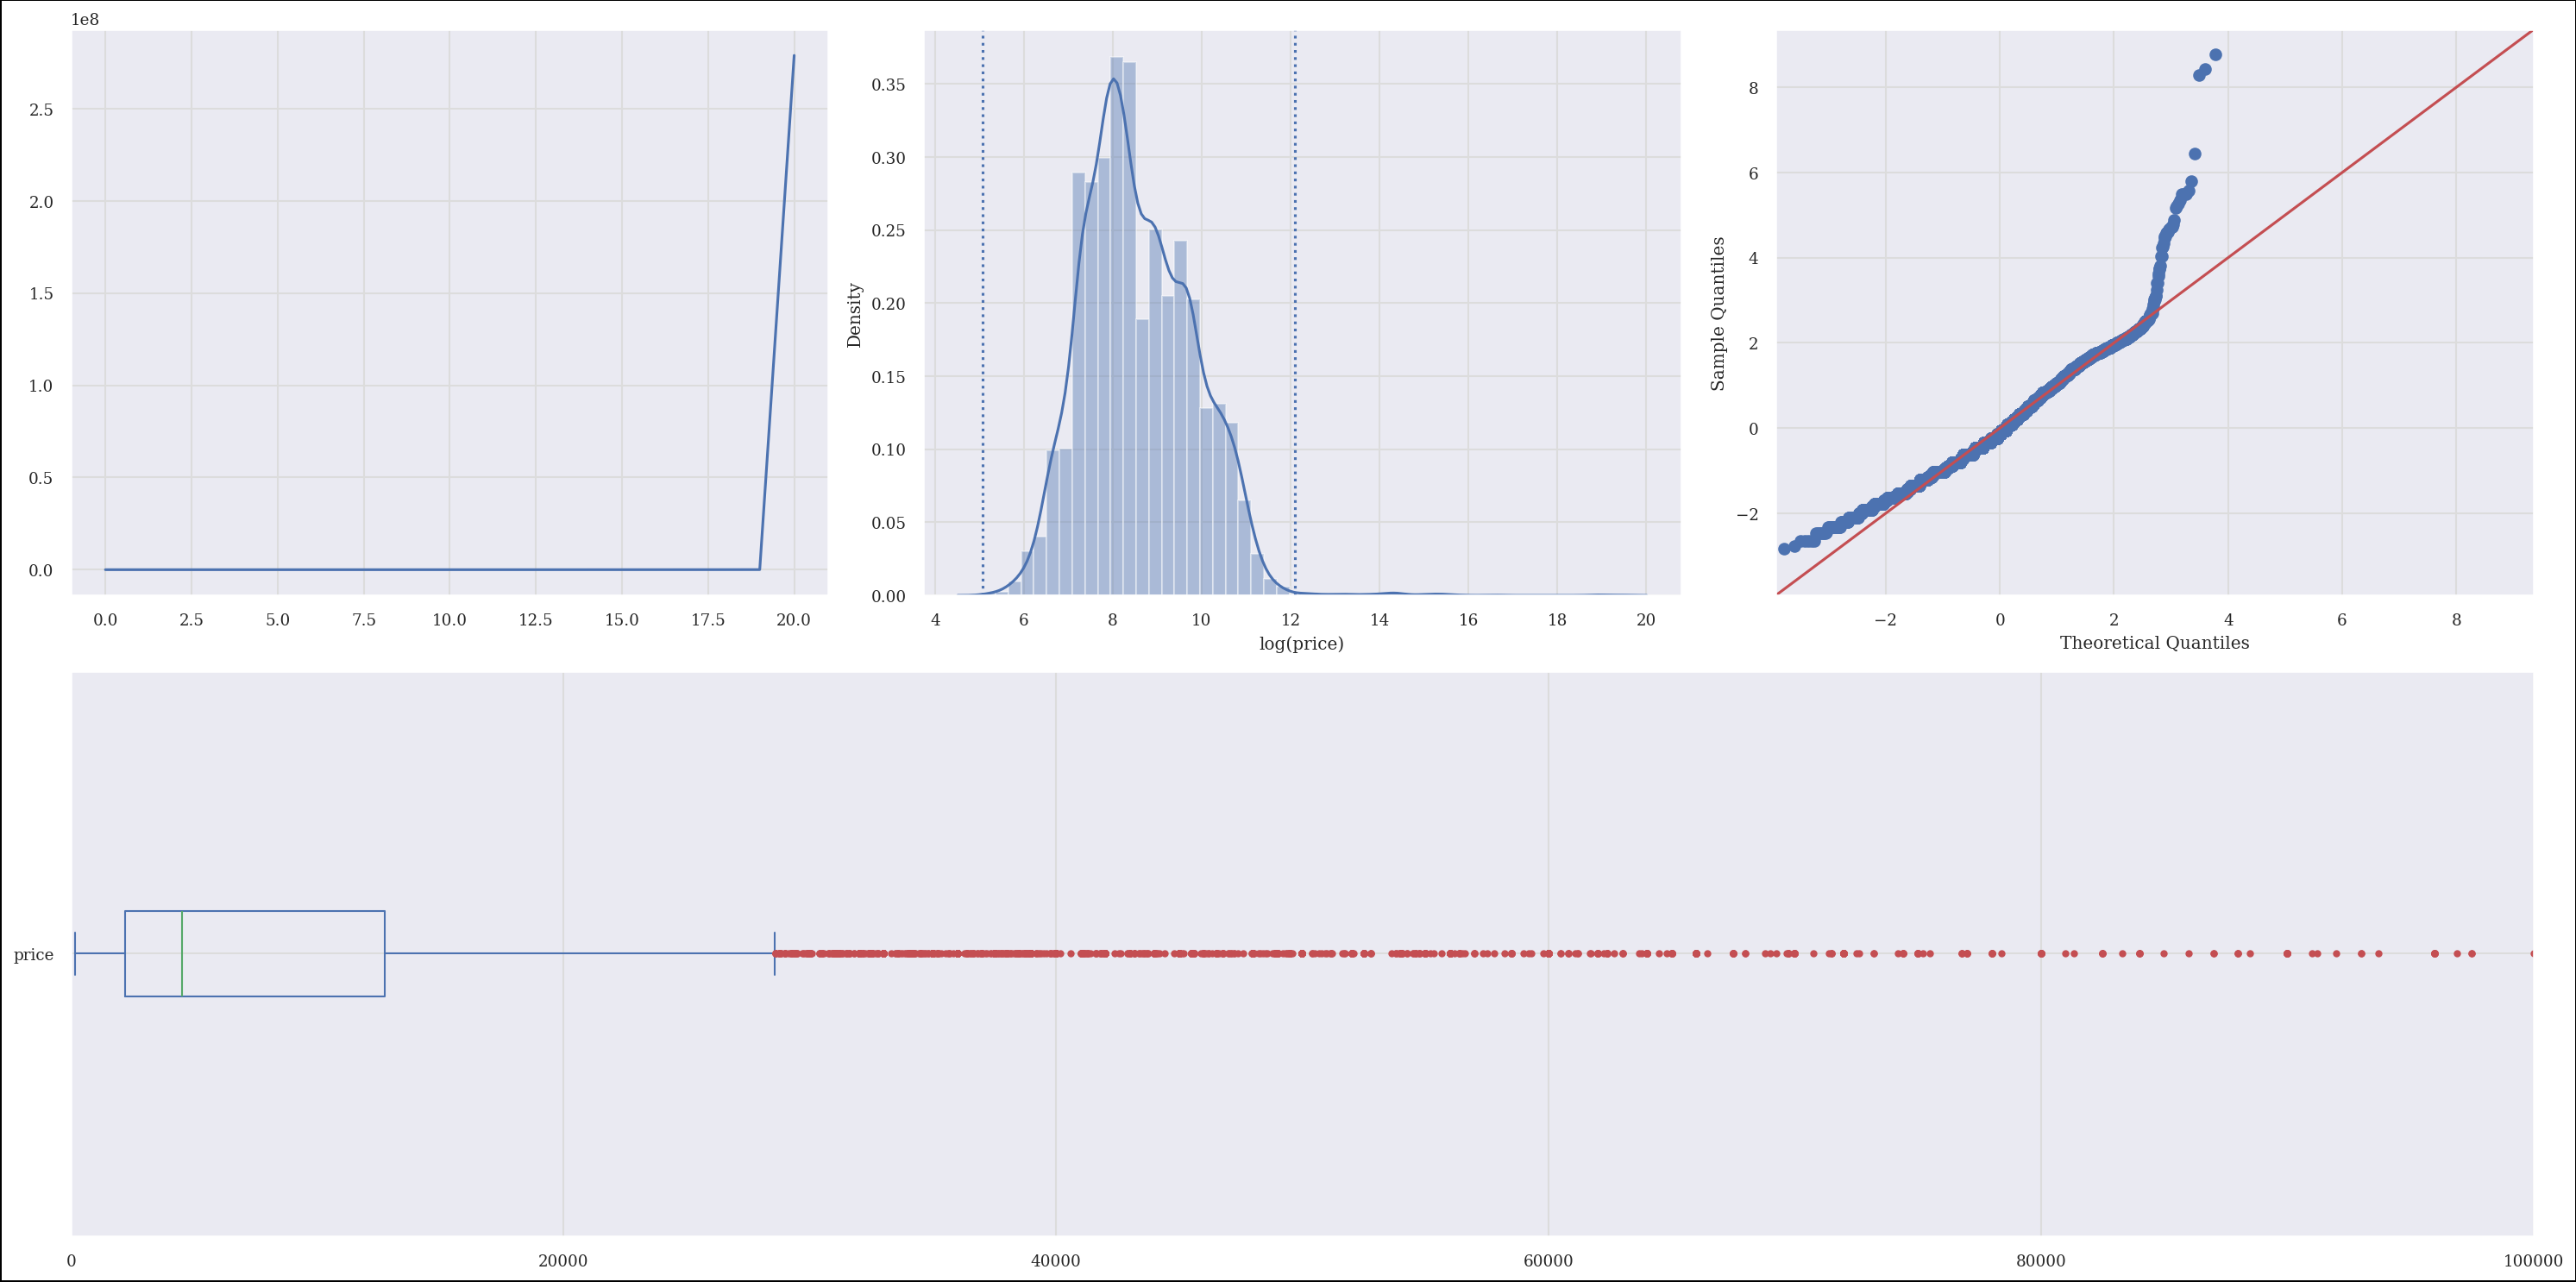

In [11]:
plot_price(train_df)

In [12]:
train_outliers = train_df[
    (np.log(train_df["price"]) < l1) | (np.log(train_df["price"]) > l2)
]

eval_outliers = eval_df[
    (np.log(eval_df["price"]) < l1) | (np.log(eval_df["price"]) > l2)
]

logger.info(
    f"{len(train_outliers)} outliers in training set and {len(eval_outliers)} outliers in evaluation set."
)

[2026-01-03 23:17:59,465: INFO: 816585731: 45 outliers in training set and 16 outliers in evaluation set.]


In [13]:
train_df = train_df.drop(index=train_outliers.index)
eval_df = eval_df.drop(index=eval_outliers.index)

Text(0.5, 1.0, 'Price distribution of training set')

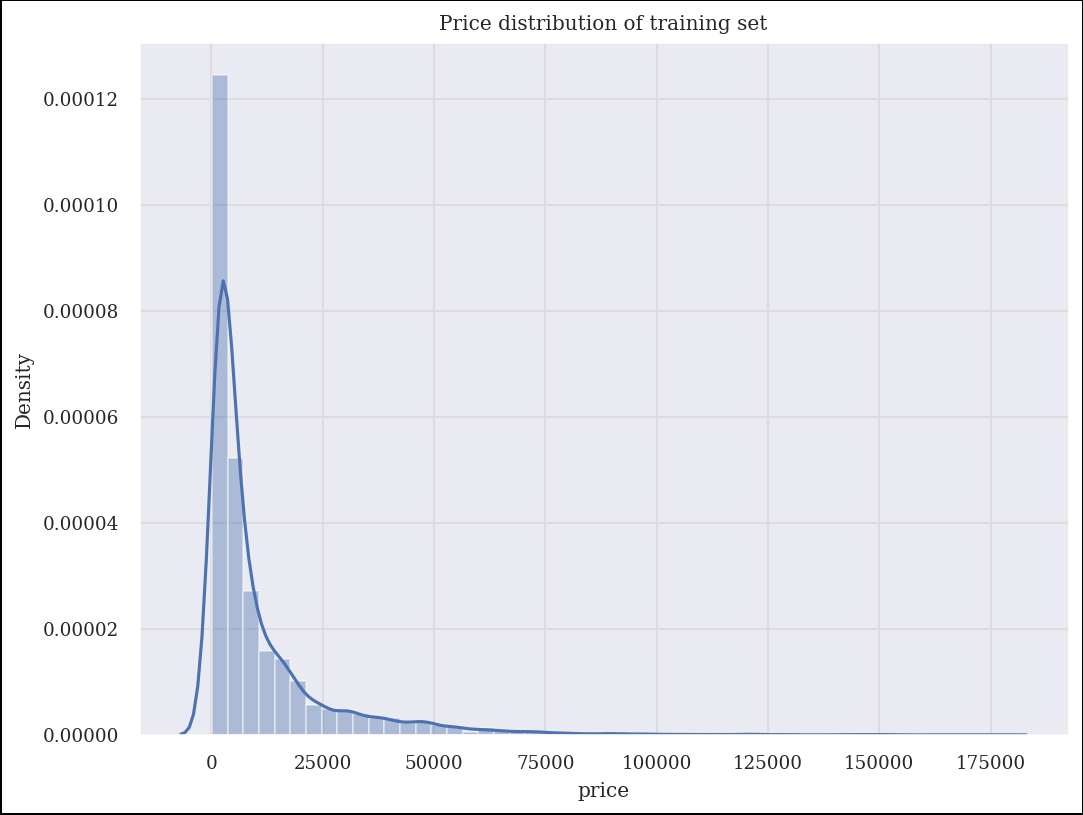

In [14]:
plt.figure(figsize=(8, 6), linewidth=1)
sns.distplot(train_df.price)
plt.title("Price distribution of training set")

# Extra Cleaning


In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12493 entries, 0 to 12537
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  12493 non-null  object 
 1   fetch_date           12493 non-null  object 
 2   house_type           12493 non-null  object 
 3   bathrooms            12493 non-null  int64  
 4   bedrooms             12493 non-null  int64  
 5   price                12493 non-null  float64
 6   locality             12493 non-null  object 
 7   Condition            12460 non-null  object 
 8   Furnishing           12493 non-null  object 
 9   Property Size        12437 non-null  float64
 10  24-hour Electricity  12493 non-null  int64  
 11  Air Conditioning     12493 non-null  int64  
 12  Apartment            12493 non-null  int64  
 13  Balcony              12493 non-null  int64  
 14  Chandelier           12493 non-null  int64  
 15  Dining Area          12493 non-null  int6

In [16]:
train_df.Condition.value_counts()

Condition
Newly-Built    6129
Fairly Used    5699
Renovated       553
Old              79
Name: count, dtype: int64

In [17]:
train_df.Condition = train_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)
eval_df.Condition = eval_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)

In [18]:
feature_columns = [
    "url",
    "house_type",
    "bathrooms",
    "bedrooms",
    "price",
    "locality",
    "lat",
    "lng",
    "Condition",
    "Furnishing",
    "24-hour Electricity",
    "Air Conditioning",
    "Apartment",
    "Balcony",
    "Chandelier",
    "Dining Area",
    "Dishwasher",
    "Hot Water",
    "Kitchen Cabinets",
    "Kitchen Shelf",
    "Microwave",
    "Pop Ceiling",
    "Pre-Paid Meter",
    "Refrigerator",
    "TV",
    "Tiled Floor",
    "Wardrobe",
    "Wi-Fi",
]

In [19]:
train_df = train_df[feature_columns]
eval_df = eval_df[feature_columns]

train_df = train_df.dropna(subset=feature_columns)
eval_df = eval_df.dropna(subset=feature_columns)

In [20]:
def rename_cols(df):
    for col in df.columns.to_list():
        df.rename(
            columns={col: col.lower().replace(" ", "_").replace("-", "_")}, inplace=True
        )
    return df

In [21]:
train_df = rename_cols(train_df)
eval_df = rename_cols(eval_df)

In [22]:
train_df.to_csv("../artifacts/data/02-preprocessed/train_df.csv", index=False)
eval_df.to_csv("../artifacts/data/02-preprocessed/eval_df.csv", index=False)

logger.info(
    f"✅ Cleaning complete, final train size: {train_df.shape}, eval size: {eval_df.shape}"
)

[2026-01-03 23:18:00,517: INFO: 2474779596: ✅ Cleaning complete, final train size: (12460, 28), eval size: (3111, 28)]
